In [15]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import torchaudio.transforms as T
import math   
from src.dataset import NSynth
import torch
from src.diffusion import *

mnist_datasets_path = r'C:\Users\Articuno\Desktop\TFG-info\data\mnist'

diff_mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff_mnist.pth'
diff_sch_mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\sch_diff_mnist.pth'

diff_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff.pth'
diff_sch_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\sch_diff.pth'

temp_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\temp.pth'
sch_temp_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\sch_temp.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')

In [16]:
# STFT transform
sample_rate = 16000
n_fft = 1500
hop_length = 250
win_length = n_fft
stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=2.0, onesided=False, center=False
).to(device)

In [17]:
import os

def train(
    model, 
    epochs=1000, 
    batch_size=16, 
    lr=1e-3, 
    model_path=None,
    sch_path=None, 
    dataset=NSynth('training'), 
    verb=False
):
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs, device=device).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
    best_loss = 1
    losses = []
    
    for epoch in range(epochs):
        for x, _ in train_loader:
            # wave = wave.to(device)
            # x = stft_transform(wave)
            
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            z, e = diffuser(x, t)
            e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        losses.append(loss.item())
            
        if epoch % 10 == 0:
            if verb:
                print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            if model_path is not None:
                torch.save(model.state_dict(), model_path)
                torch.save(scheduler.state_dict(), sch_path)
                if verb:
                    print(f"Model temporally saved at epoch {epoch} with loss {best_loss}")
            else:
                torch.save(model.state_dict(), temp_path)
                torch.save(scheduler.state_dict(), sch_temp_path)
                if verb:
                    print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    if model_path is not None:
        model.load_state_dict(torch.load(model_path))
        scheduler.load_state_dict(torch.load(sch_path))
    else:
        model.load_state_dict(torch.load(temp_path))
        scheduler.load_state_dict(torch.load(sch_temp_path))

        # eliminar temp?
        
    print("Training completed., best loss:", best_loss)
    
    return model, scheduler, losses
    

In [62]:
@torch.no_grad()
def sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()

    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)

    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # predicción de ruido
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        
        # beta_t = beta_t.view(1,1,1,1)
        # alpha_t = alpha_t.view(1,1,1,1)
        # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


        # Coeficientes DDPM
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise
        else:
            x = mu

    x = x.clamp(0, 1).cpu()

    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()

    return x

@torch.no_grad()
def remove_noise(model, scheduler, image_size=(1, 28, 28), x=None, alpha=0):
    model.eval()
    if x is None:
        x = torch.randn(1, *image_size, device=device)
        alpha = 1

    # Guardar imagen original
    x_original = x.clone().cpu()

    # Añadir ruido
    noise = torch.randn(1, *image_size, device=device) * (1 - alpha)
    x_noisy = x * alpha + noise
    x = x_noisy.clone()  # este será el tensor que pasaremos al DDPM

    T = scheduler.beta.size(0)
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)
        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise_step = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise_step
        else:
            x = mu

    x_denoised = x.clamp(0, 1).cpu()

    # Mostrar imágenes: original, con ruido, denoised
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))
    axes[0].imshow(x_original[0, 0], cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(x_noisy[0, 0].cpu(), cmap='gray')
    axes[1].set_title('Noisy')
    axes[1].axis('off')

    axes[2].imshow(x_denoised[0, 0], cmap='gray')
    axes[2].set_title('Denoised')
    axes[2].axis('off')

    plt.show()

    return x_denoised



In [19]:
def createObjects(epochs=1000, norm_groups=8, sin=128, sout=None):
    sout = sout or sin
    
    down_layers = [
        DummyLayer(sin, sin//2, norm_groups).to(device),
        DummyLayer(sin//2, sin//4, norm_groups).to(device),
    ]

    bottleneck = DummyLayer(sin//4, sout//4, norm_groups).to(device)

    up_layers = [
        DummyLayer(sout//4, sout//2, norm_groups).to(device),
        DummyLayer(sout//2, sout, norm_groups).to(device),
    ]

    embedder = Embeder(num_epochs=epochs, embed_dim=128, device=device).to(device)
    scheduler = Scheduler(num_epochs=epochs, device=device).to(device)

    model = DiffusionModel(
        channels=[sin, sout], # entrada y salida de las layers
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)

    losses = []
    return model, scheduler, losses

In [20]:
mnist_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())
synt_ds = NSynth('training')

In [21]:
num_epochs = 100
batch_size = 2048
sin = 128
sout = sin # por ahora tiene pinta de que deben de ser iguales (por lo de los skips)
norm_groups = 8

In [22]:
%%time
model, shceduler, losses = createObjects(num_epochs, norm_groups, sin, sout)

CPU times: total: 15.6 ms
Wall time: 15.7 ms


Epoch 0, Loss: 0.32088541984558105
Model temporally saved at epoch 0 with loss 0.32088541984558105
Model temporally saved at epoch 1 with loss 0.27223122119903564
Model temporally saved at epoch 2 with loss 0.23961330950260162
Model temporally saved at epoch 3 with loss 0.23288150131702423
Model temporally saved at epoch 4 with loss 0.22009208798408508
Model temporally saved at epoch 5 with loss 0.20432743430137634
Model temporally saved at epoch 6 with loss 0.19105775654315948
Model temporally saved at epoch 7 with loss 0.18007197976112366
Model temporally saved at epoch 8 with loss 0.17883919179439545
Model temporally saved at epoch 9 with loss 0.16016660630702972
Epoch 10, Loss: 0.1662481278181076
Model temporally saved at epoch 13 with loss 0.15415462851524353
Model temporally saved at epoch 14 with loss 0.14757832884788513
Model temporally saved at epoch 19 with loss 0.1461745798587799
Epoch 20, Loss: 0.14011618494987488
Model temporally saved at epoch 20 with loss 0.1401161849498

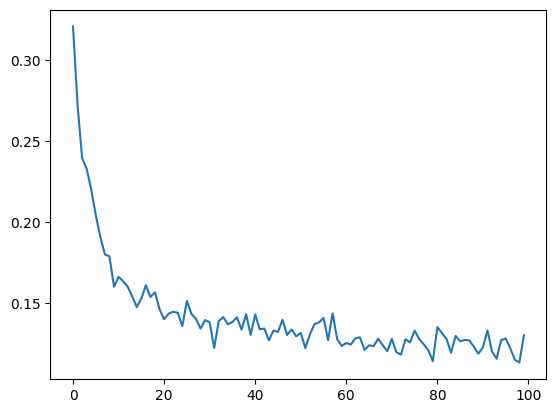

In [23]:
%%time
model, scheduler, losses = train(
    model, 
    epochs=num_epochs,
    batch_size=2048, 
    lr=1e-3, 
    model_path=diff_mnist_model_path, 
    sch_path=diff_sch_mnist_model_path,
    dataset=mnist_ds,
    verb=True,
)
plt.plot(losses)

In [24]:
# model, scheduler, losses = createObjects(num_epochs, norm_groups, sin, sout)
# scheduler.load_state_dict(torch.load(diff_sch_mnist_model_path))
# model.load_state_dict(torch.load(diff_mnist_model_path))


In [25]:
# print('Losses:')
# plt.plot(losses)

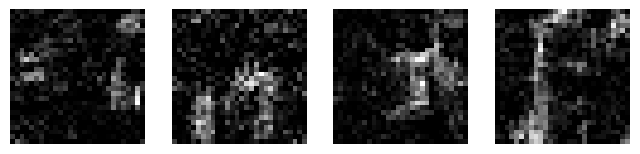

In [36]:
_ = sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28))

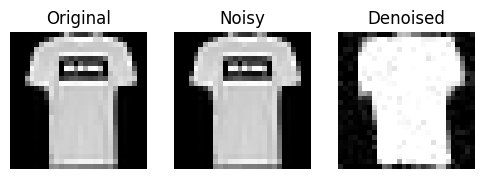

In [86]:
x, _ = mnist_ds[1]
x = x = x.unsqueeze(0).to(device)  # agregar dimensión batch y mover a device
_ = remove_noise(model, scheduler, (1, 28, 28), x, 1)

<!-- Problemas: a veces sale muy poco loss y es porque sale todo en negro :/ -->
